<h3>INPUT DATASET<h3>

In [1]:
from pathlib import Path
import pandas as pd
import zipfile
import urllib.request

def load_mobile_data():
    zip_path = Path("datasets/mobile_price.zip")
    
    if not zip_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://www.kaggle.com/api/v1/datasets/download/mohannapd/mobile-price-prediction"
        urllib.request.urlretrieve(url, zip_path)
        
    with zipfile.ZipFile(zip_path) as mobile_zip:
        mobile_zip.extractall(path="datasets")
        
    return pd.read_csv(Path("datasets/mobile_price.csv"))

mobile = load_mobile_data()

In [3]:
mobile.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


In [5]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Brand                   407 non-null    object
 1   Model                   407 non-null    object
 2   Storage                 407 non-null    object
 3   RAM                     407 non-null    object
 4   Screen Size (inches)    407 non-null    object
 5   Camera (MP)             407 non-null    object
 6   Battery Capacity (mAh)  407 non-null    int64 
 7   Price ($)               407 non-null    object
dtypes: int64(1), object(7)
memory usage: 25.6+ KB


<h3>DATA CLEANING</h3>

In [8]:
mobile.rename(columns={"Storage ": "Storage (GB)", "RAM ": "RAM (GB)"}, inplace=True)

In [10]:
mobile.columns

Index(['Brand', 'Model', 'Storage (GB)', 'RAM (GB)', 'Screen Size (inches)',
       'Camera (MP)', 'Battery Capacity (mAh)', 'Price ($)'],
      dtype='object')

In [12]:
mobile["Storage (GB)"] = mobile["Storage (GB)"].str.extract(r"(\d+)").astype("int64")
mobile["RAM (GB)"] = mobile["RAM (GB)"].str.extract(r"(\d+)").astype("int64")
mobile["Screen Size (inches)"] = mobile["Screen Size (inches)"].astype(str).str.extract(r"(\d+\.?\d*)").astype(float)

In [14]:
# 1. Remove commas and dollar signs, strip whitespace, then convert to int64
mobile["Price ($)"] = (
    mobile["Price ($)"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .str.strip()
    .astype("int64")
)

In [16]:
# 1. Clean the text: remove 'MP'/'mp', strip extra spaces around '+'
mobile['Camera (MP)'] = (
    mobile['Camera (MP)']
    .astype(str)
    .str.replace(r'(?i)mp', '', regex=True)
    .str.replace(r'\s*\+\s*', ' + ', regex=True)
    .str.strip()
)

In [18]:
mobile["Number of Rear Cameras"] = mobile["Camera (MP)"].str.count(r"\+") + 1

In [20]:
mobile[["Camera (MP)", "Number of Rear Cameras"]].head()

,Camera (MP),Number of Rear Cameras
0,12 + 12 + 12,3
1,108 + 10 + 10 + 12,4
2,48 + 50 + 8 + 2,4
3,64 + 8 + 5 + 2,4
4,50 + 12.2,2


In [22]:
mobile.head()

,Brand,Model,Storage (GB),RAM (GB),Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($),Number of Rear Cameras
0,Apple,iPhone 13 Pro,128,6,6.10,12 + 12 + 12,3095,999,3
1,Samsung,Galaxy S21 Ultra,256,12,6.80,108 + 10 + 10 + 12,5000,1199,4
2,OnePlus,9 Pro,128,8,6.70,48 + 50 + 8 + 2,4500,899,4
3,Xiaomi,Redmi Note 10 Pro,128,6,6.67,64 + 8 + 5 + 2,5020,279,4
4,Google,Pixel 6,128,8,6.40,50 + 12.2,4614,799,2


In [24]:
mobile.duplicated().sum()

49

In [26]:
mobile = mobile.drop_duplicates().reset_index(drop=True)

In [28]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brand                   358 non-null    object 
 1   Model                   358 non-null    object 
 2   Storage (GB)            358 non-null    int64  
 3   RAM (GB)                358 non-null    int64  
 4   Screen Size (inches)    358 non-null    float64
 5   Camera (MP)             358 non-null    object 
 6   Battery Capacity (mAh)  358 non-null    int64  
 7   Price ($)               358 non-null    int64  
 8   Number of Rear Cameras  358 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 25.3+ KB


In [30]:
mobile.describe()

,Storage (GB),RAM (GB),Screen Size (inches),Battery Capacity (mAh),Price ($),Number of Rear Cameras
count,358.000000,358.000000,358.000000,358.000000,358.000000,358.000000
mean,125.050279,5.910615,6.481508,4695.363128,411.991620,3.145251
std,67.913050,2.510002,0.302918,780.972153,310.076059,0.760449
min,32.000000,2.000000,4.500000,1821.000000,99.000000,1.000000
25%,64.000000,4.000000,6.440000,4300.000000,199.000000,3.000000
50%,128.000000,6.000000,6.500000,5000.000000,299.000000,3.000000
75%,128.000000,8.000000,6.600000,5000.000000,499.000000,4.000000
max,512.000000,16.000000,7.600000,7000.000000,1999.000000,4.000000


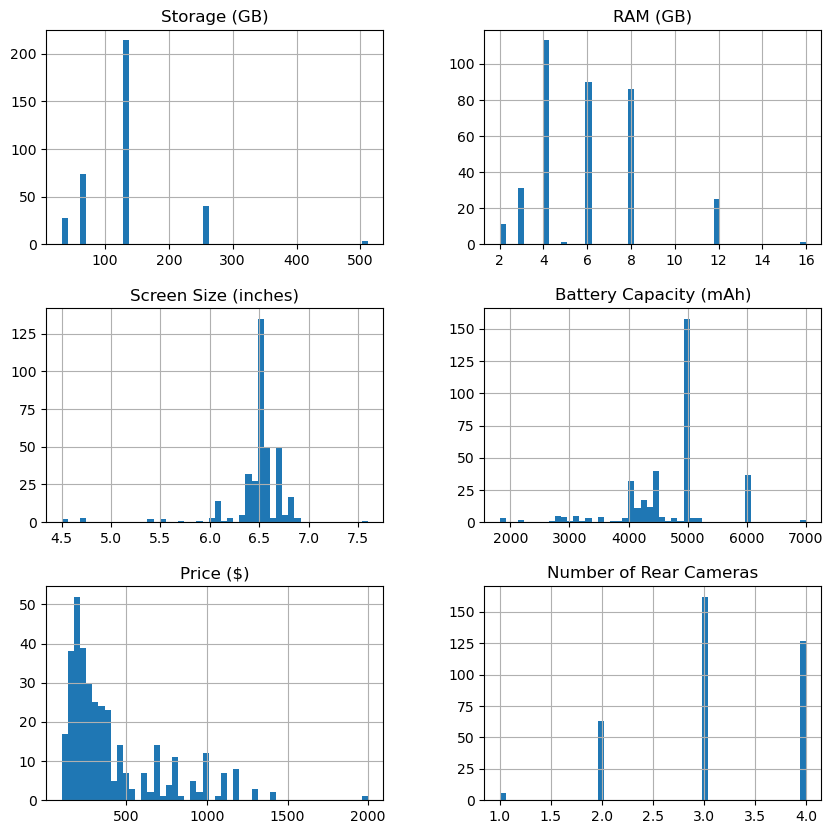

In [32]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=5)
plt.rc('axes', labelsize=10, titlesize=12)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

mobile.hist(bins=50, figsize=(10, 10))
plt.show()

<H3>SPLITTING TEST SET AND TRAIN SET <H3>

In [34]:
from zlib import crc32
import numpy as np

# Create a unique ID string from stable features
mobile_with_id = mobile.copy()
mobile_with_id["id_str"] = (
    mobile["Brand"] + "_" + 
    mobile["Model"] + "_" + 
    mobile["Storage (GB)"].astype(str) + "_" + 
    mobile["RAM (GB)"].astype(str)
)

# Hash the string ID
def is_str_id_in_test_set(identifier, test_ratio):
    return crc32(identifier.encode('utf-8')) < test_ratio * 2**32

def split_data_with_str_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_str_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

train_set, test_set = split_data_with_str_id_hash(mobile_with_id, 0.2, "id_str")

In [37]:
len(train_set)

300

In [39]:
len(test_set)

58

In [41]:
X_train = train_set.drop(["Camera (MP)", "Price ($)","Model"], axis=1)
y_train = train_set["Price ($)"].copy()

In [43]:
X_test = test_set.drop(["Camera (MP)", "Price ($)","Model"], axis=1)
y_test = test_set["Price ($)"].copy()

<h3>EDA EXPLORATION DATA ANAYLSIS <h3>

In [46]:
mobile_eda = train_set.copy() 

In [48]:
corr_matrix = mobile_eda.corr(numeric_only=True)

print(corr_matrix["Price ($)"].sort_values(ascending=False))

Price ($)                 1.000000
Storage (GB)              0.724543
RAM (GB)                  0.642858
Number of Rear Cameras    0.098685
Screen Size (inches)      0.043066
Battery Capacity (mAh)   -0.384275
Name: Price ($), dtype: float64


array([[<Axes: xlabel='Price ($)', ylabel='Price ($)'>,
        <Axes: xlabel='RAM (GB)', ylabel='Price ($)'>,
        <Axes: xlabel='Storage (GB)', ylabel='Price ($)'>,
        <Axes: xlabel='Number of Rear Cameras', ylabel='Price ($)'>,
        <Axes: xlabel='Screen Size (inches)', ylabel='Price ($)'>,
        <Axes: xlabel='Battery Capacity (mAh)', ylabel='Price ($)'>],
       [<Axes: xlabel='Price ($)', ylabel='RAM (GB)'>,
        <Axes: xlabel='RAM (GB)', ylabel='RAM (GB)'>,
        <Axes: xlabel='Storage (GB)', ylabel='RAM (GB)'>,
        <Axes: xlabel='Number of Rear Cameras', ylabel='RAM (GB)'>,
        <Axes: xlabel='Screen Size (inches)', ylabel='RAM (GB)'>,
        <Axes: xlabel='Battery Capacity (mAh)', ylabel='RAM (GB)'>],
       [<Axes: xlabel='Price ($)', ylabel='Storage (GB)'>,
        <Axes: xlabel='RAM (GB)', ylabel='Storage (GB)'>,
        <Axes: xlabel='Storage (GB)', ylabel='Storage (GB)'>,
        <Axes: xlabel='Number of Rear Cameras', ylabel='Storage (GB)'>,
   

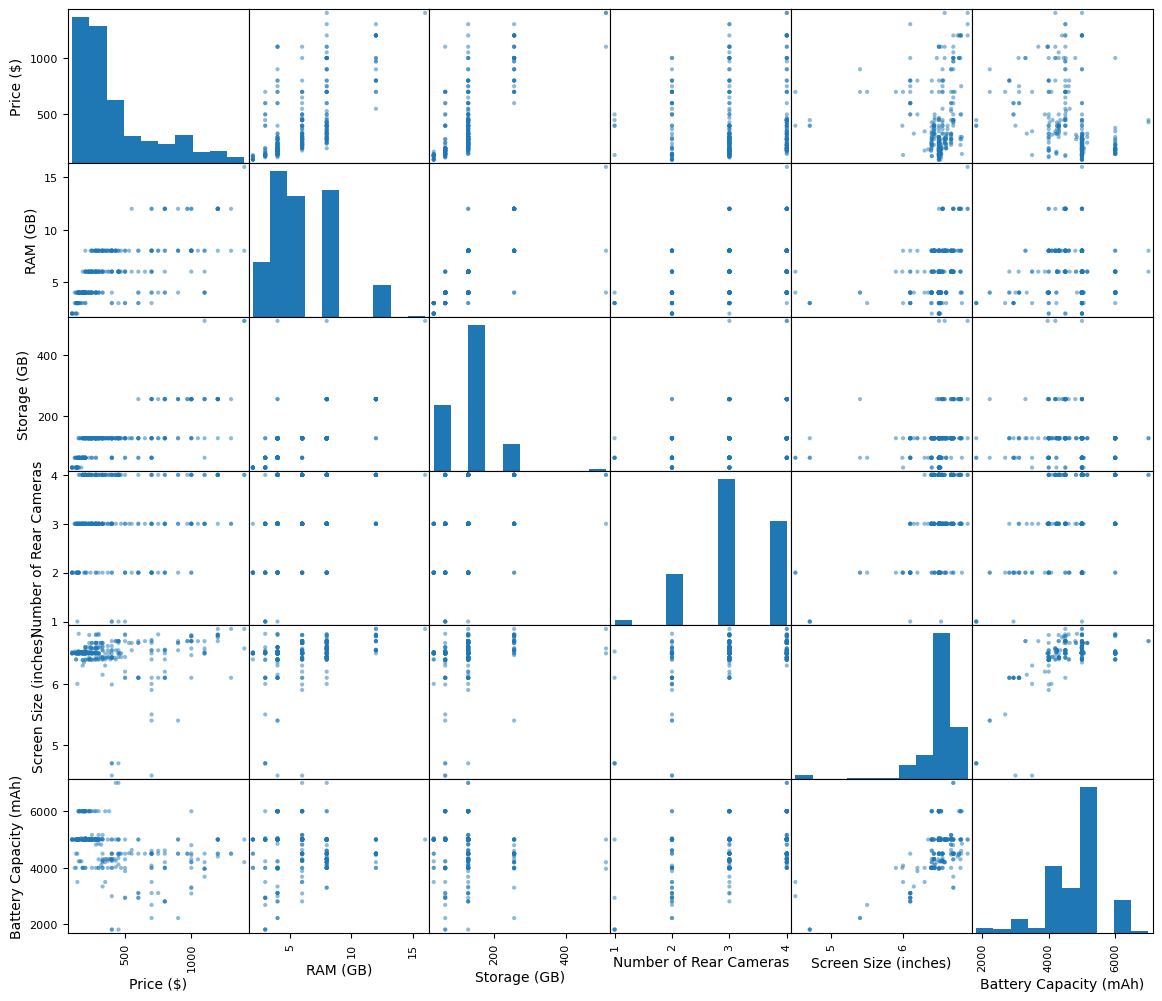

In [50]:
from pandas.plotting import scatter_matrix

# Select top target features to plot
attributes = ["Price ($)", "RAM (GB)", "Storage (GB)", "Number of Rear Cameras", "Screen Size (inches)","Battery Capacity (mAh)"]
scatter_matrix(mobile_eda[attributes], figsize=(14, 12))

<h3>AUTOMATED PIPELINE <h3>

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Define numerical and categorical feature lists
num_cols = [
    "Storage (GB)",
    "RAM (GB)",
    "Screen Size (inches)",
    "Battery Capacity (mAh)",
    "Number of Rear Cameras"
]
cat_cols = ["Brand"]

# 2. Create sub-pipelines for numerical and categorical preprocessing
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 3. Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)

# 4. Fit on training data and transform both train and test sets
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f"X_train_prepared shape: {X_train_prepared.shape}")
print(f"X_test_prepared shape:  {X_test_prepared.shape}")

X_train_prepared shape: (300, 20)
X_test_prepared shape:  (58, 20)


In [54]:
# Retrieve column names generated by ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# Convert the NumPy array to a DataFrame for inspection
X_train_df = pd.DataFrame(X_train_prepared, columns=feature_names)
X_train_df.head()

,num__Storage (GB),num__RAM (GB),num__Screen Size (inches),num__Battery Capacity (mAh),num__Number of Rear Cameras,cat__Brand_Apple,cat__Brand_Asus,cat__Brand_Blackberry,cat__Brand_Google,cat__Brand_Huawei,cat__Brand_LG,cat__Brand_Motorola,cat__Brand_Nokia,cat__Brand_OnePlus,cat__Brand_Oppo,cat__Brand_Realme,cat__Brand_Samsung,cat__Brand_Sony,cat__Brand_Vivo,cat__Brand_Xiaomi
0,0.016982,0.006678,-1.215487,-2.008477,-0.188139,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.869551,2.410580,1.041585,0.388414,1.155708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.016982,0.807978,0.719146,-0.240691,1.155708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.016982,0.807978,-0.248171,-0.097255,-1.531985,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.016982,-0.794623,-1.215487,-2.360776,-1.531985,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<h3>CHOOSING THE RIGHT ALGORITHM <h3>

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

# Define baseline models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    # 1. Training Set Evaluation (Simple fit & predict)
    model.fit(X_train_prepared, y_train)
    
    y_train_pred = model.predict(X_train_prepared)
    
    train_rmse = root_mean_squared_error(y_train, y_train_pred)

    # 2. 5-Fold Cross-Validation Evaluation
    cv_scores = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5,
    )
    
    cv_rmse_scores = -cv_scores

    # Store combined metrics
    results[name] = {
        "Train RMSE ($)": np.round(train_rmse, 2),
        "CV Mean RMSE ($)": np.round(cv_rmse_scores.mean(), 2),
        "CV Std Dev ($)": np.round(cv_rmse_scores.std(), 2),
    }

# Display summary comparison table sorted by cross-validation performance
results_df = pd.DataFrame(results).T
results_df.sort_values(by="CV Mean RMSE ($)")

,Train RMSE ($),CV Mean RMSE ($),CV Std Dev ($)
Decision Tree,20.99,138.76,74.16
Linear Regression,117.51,150.66,50.97


<H3>ADDING NEW FEATURES LIKE BRAND VALUE, SERVICE SCORE, CATEGORY IN THE ABOVE PIPELINE</H3>

In [61]:
from sklearn.base import BaseEstimator, TransformerMixin

class BrandValueAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.brand_value_map = {
            'Apple': 9.8, 'Samsung': 9.0, 'Google': 8.5, 'OnePlus': 8.0,
            'Sony': 7.5, 'Asus': 7.2, 'Xiaomi': 7.0, 'Huawei': 6.8,
            'Oppo': 6.5, 'Vivo': 6.5, 'Motorola': 6.2, 'Realme': 6.0,
            'Nokia': 5.5, 'Blackberry': 5.0, 'LG': 5.0
        }
        self.default_score = 5.0

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out['Brand Value Score'] = (
            X_out['Brand'].astype(str).str.strip()
            .map(self.brand_value_map)
            .fillna(self.default_score)
        )
        return X_out

# Test Step 1 on X_train
step1_transformer = BrandValueAdder()
X_train_step1 = step1_transformer.transform(X_train)
X_train_step1[['Brand', 'Brand Value Score']].head()

,Brand,Brand Value Score
0,Apple,9.8
1,Samsung,9.0
2,OnePlus,8.0
4,Google,8.5
5,Apple,9.8


In [63]:
class ServiceScoreAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.service_score_map = {
            'Apple': 9.5, 'Samsung': 9.0, 'Xiaomi': 8.2, 'Oppo': 7.8,
            'Vivo': 7.8, 'OnePlus': 7.5, 'Realme': 7.5, 'Google': 7.0,
            'Motorola': 7.0, 'Asus': 6.8, 'Nokia': 6.5, 'Sony': 6.2,
            'Huawei': 6.0, 'LG': 5.0, 'Blackberry': 4.0
        }
        self.default_score = 5.0

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out['Service Score'] = (
            X_out['Brand'].astype(str).str.strip()
            .map(self.service_score_map)
            .fillna(self.default_score)
        )
        return X_out

# Test Step 2 on X_train_step1
step2_transformer = ServiceScoreAdder()
X_train_step2 = step2_transformer.transform(X_train_step1)
X_train_step2[['Brand', 'Brand Value Score', 'Service Score']].head()

,Brand,Brand Value Score,Service Score
0,Apple,9.8,9.5
1,Samsung,9.0,9.0
2,OnePlus,8.0,7.5
4,Google,8.5,7.0
5,Apple,9.8,9.5


In [65]:
class SpecTierClassifier(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        
        def assign_tier(row):
            ram = row.get('RAM (GB)', 4)
            storage = row.get('Storage (GB)', 64)
            
            if ram >= 8 and storage >= 256:
                return 'Flagship'
            elif ram <= 4 and storage <= 64:
                return 'Budget'
            else:
                return 'Mid-Range'
                
        X_out['Spec Tier'] = X_out.apply(assign_tier, axis=1)
        return X_out

# Test Step 3 on X_train_step2
step3_transformer = SpecTierClassifier()
X_train_step3 = step3_transformer.transform(X_train_step2)
X_train_step3[['RAM (GB)', 'Storage (GB)', 'Spec Tier']].head()

,RAM (GB),Storage (GB),Spec Tier
0,6,128,Mid-Range
1,12,256,Flagship
2,8,128,Mid-Range
4,8,128,Mid-Range
5,4,128,Mid-Range


In [67]:
# 1. Update feature column lists with the new features
num_cols_extended = [
    "Storage (GB)",
    "RAM (GB)",
    "Screen Size (inches)",
    "Battery Capacity (mAh)",
    "Number of Rear Cameras",
    "Brand Value Score",
    "Service Score"
]

cat_cols_extended = ["Brand", "Spec Tier"]

# 2. Define standard sub-pipelines
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 3. Combine sub-pipelines with ColumnTransformer
encoding_transformer = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols_extended),
        ("cat", cat_pipeline, cat_cols_extended)
    ]
)

# 4. Master Sequential Pipeline applying transformers one-by-one
full_feature_pipeline = Pipeline([
    ("add_brand_value", BrandValueAdder()),
    ("add_service_score", ServiceScoreAdder()),
    ("add_spec_tier", SpecTierClassifier()),
    ("preprocessor", encoding_transformer)
])

# 5. Fit & transform training and test data
X_train_prepared = full_feature_pipeline.fit_transform(X_train)
X_test_prepared = full_feature_pipeline.transform(X_test)

print(f"New X_train_prepared shape: {X_train_prepared.shape}")
print(f"New X_test_prepared shape:  {X_test_prepared.shape}")

New X_train_prepared shape: (300, 25)
New X_test_prepared shape:  (58, 25)


In [69]:
# 1. Extract the 25 feature names from the last step of the pipeline 
#.named_steps act like dictionary like pulling final pipeline table from ("preprocessar" , encoding_transformer)
feature_names = full_feature_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 2. Convert the NumPy array into a pandas DataFrame
X_train_prepared_df = pd.DataFrame(
    X_train_prepared, 
    columns=feature_names, 
    index=X_train.index
)

# 3. Display the DataFrame
X_train_prepared_df.head()

,num__Storage (GB),num__RAM (GB),num__Screen Size (inches),num__Battery Capacity (mAh),num__Number of Rear Cameras,num__Brand Value Score,num__Service Score,cat__Brand_Apple,cat__Brand_Asus,cat__Brand_Blackberry,...,cat__Brand_OnePlus,cat__Brand_Oppo,cat__Brand_Realme,cat__Brand_Samsung,cat__Brand_Sony,cat__Brand_Vivo,cat__Brand_Xiaomi,cat__Spec Tier_Budget,cat__Spec Tier_Flagship,cat__Spec Tier_Mid-Range
0,0.016982,0.006678,-1.215487,-2.008477,-0.188139,1.964000,1.632661,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.869551,2.410580,1.041585,0.388414,1.155708,1.356968,1.129375,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.016982,0.807978,0.719146,-0.240691,1.155708,0.598179,-0.380485,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.016982,0.807978,-0.248171,-0.097255,-1.531985,0.977574,-0.883771,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.016982,-0.794623,-1.215487,-2.360776,-1.531985,1.964000,1.632661,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


<H3>SIMPLE TRAINING AND CROSS VALIDATION TRAINING TEST </H3>

In [72]:
# 1. Initialize and fit Linear Regression on the new prepared features
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

# 2. Training Set Evaluation (single fit on entire train set)
y_train_pred = lin_reg.predict(X_train_prepared)
train_rmse = root_mean_squared_error(y_train, y_train_pred)

# 3. 5-Fold Cross-Validation Evaluation (testing generalization on train folds)
cv_scores = cross_val_score(
    lin_reg,
    X_train_prepared,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)
cv_rmse_scores = -cv_scores
cv_mean_rmse = cv_rmse_scores.mean()
cv_std_rmse = cv_rmse_scores.std()

# 4. Display Training vs. CV comparison
print("=" * 48)
print("   TRAIN & CROSS-VALIDATION EVALUATION (NEW FEATURES)   ")
print("=" * 48)
print(f"Single Train Set RMSE (Without CV) : ${train_rmse:.2f}")
print(f"5-Fold CV Mean RMSE (With CV)      : ${cv_mean_rmse:.2f}")
print(f"5-Fold CV Standard Deviation       : ${cv_std_rmse:.2f}")
print("-" * 48)
print(f"Variance Gap (CV - Train)          : ${cv_mean_rmse - train_rmse:.2f}")
print("=" * 48)

   TRAIN & CROSS-VALIDATION EVALUATION (NEW FEATURES)   
Single Train Set RMSE (Without CV) : $108.21
5-Fold CV Mean RMSE (With CV)      : $140.21
5-Fold CV Standard Deviation       : $62.15
------------------------------------------------
Variance Gap (CV - Train)          : $32.00


<H3>FINAL TEST ON TEST SET </H3>

In [75]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. Predict on unseen Test Data
y_test_pred = lin_reg.predict(X_test_prepared)

# 2. Compute Test Metrics
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_accuracy = (1 - test_mape) * 100

within_10_pct = np.mean(np.abs((y_test - y_test_pred) / y_test) <= 0.10) * 100
within_15_pct = np.mean(np.abs((y_test - y_test_pred) / y_test) <= 0.15) * 100

# 3. Display Full Project Scorecard
print("=" * 48)
print("            FINAL TEST SET SCORECARD            ")
print("=" * 48)
print(f"Train RMSE                         : ${train_rmse:.2f}")
print(f"5-Fold CV Mean RMSE                : ${cv_mean_rmse:.2f}")
print(f"Final Test Set RMSE                : ${test_rmse:.2f}")
print("-" * 48)
print(f"Test MAE (Average Error in $)      : ${test_mae:.2f}")
print(f"Test R² Score (Variance Explained) : {test_r2 * 100:.2f}%")
print(f"Prediction Accuracy (1 - MAPE)     : {test_accuracy:.2f}%")
print("-" * 48)
print(f"Predictions within ±10% of Price   : {within_10_pct:.1f}%")
print(f"Predictions within ±15% of Price   : {within_15_pct:.1f}%")
print("=" * 48)

            FINAL TEST SET SCORECARD            
Train RMSE                         : $108.21
5-Fold CV Mean RMSE                : $140.21
Final Test Set RMSE                : $125.99
------------------------------------------------
Test MAE (Average Error in $)      : $74.41
Test R² Score (Variance Explained) : 85.94%
Prediction Accuracy (1 - MAPE)     : 78.72%
------------------------------------------------
Predictions within ±10% of Price   : 32.8%
Predictions within ±15% of Price   : 46.6%


<h3>LOG TRANFORMATION OF THE Y TARGET VARIABLE </h3>

In [78]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.linear_model import Ridge

# 1. Wrap Ridge Regression with a Log1p Target Transformation
base_ridge = Ridge(alpha=0.5, random_state=42)

log_model = TransformedTargetRegressor(
    regressor=base_ridge, func=np.log1p, inverse_func=np.expm1
)

# 2. Fit on training data and cross-validate
log_model.fit(X_train_prepared, y_train)

cv_scores = cross_val_score(
    log_model,
    X_train_prepared,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5,
)
cv_mean_rmse = -cv_scores.mean()

# 3. Predict on unseen Test Data
y_test_pred_log = log_model.predict(X_test_prepared)

# 4. Compute Test Metrics
test_rmse = root_mean_squared_error(y_test, y_test_pred_log)
test_mae = mean_absolute_error(y_test, y_test_pred_log)
test_r2 = r2_score(y_test, y_test_pred_log)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred_log)
test_accuracy = (1 - test_mape) * 100

within_10_pct = (
    np.mean(np.abs((y_test - y_test_pred_log) / y_test) <= 0.10) * 100
)
within_15_pct = (
    np.mean(np.abs((y_test - y_test_pred_log) / y_test) <= 0.15) * 100
)

# 5. Display Scorecard
print("=" * 48)
print("     LOG-TRANSFORMED TARGET SCORECARD (RIDGE)     ")
print("=" * 48)
print(f"5-Fold CV Mean RMSE                : ${cv_mean_rmse:.2f}")
print(f"Final Test Set RMSE                : ${test_rmse:.2f}")
print("-" * 48)
print(f"Test MAE (Average Error in $)      : ${test_mae:.2f}")
print(f"Test R² Score (Variance Explained) : {test_r2 * 100:.2f}%")
print(f"Prediction Accuracy (1 - MAPE)     : {test_accuracy:.2f}%")
print("-" * 48)
print(f"Predictions within ±10% of Price   : {within_10_pct:.1f}%")
print(f"Predictions within ±15% of Price   : {within_15_pct:.1f}%")
print("=" * 48)

     LOG-TRANSFORMED TARGET SCORECARD (RIDGE)     
5-Fold CV Mean RMSE                : $157.34
Final Test Set RMSE                : $93.63
------------------------------------------------
Test MAE (Average Error in $)      : $59.39
Test R² Score (Variance Explained) : 92.23%
Prediction Accuracy (1 - MAPE)     : 84.07%
------------------------------------------------
Predictions within ±10% of Price   : 41.4%
Predictions within ±15% of Price   : 51.7%


<H3>BATCH GRADIENT DESCENT ON THE FINAL TEST</H3>

In [81]:
# 1. Prepare Features & Target (from your existing pipeline)
# X_train_prepared: (300, 25) shape array
# X_test_prepared:  (58, 25) shape array

# Add the bias column (x0 = 1) to both train and test feature matrices
X_b_train = np.c_[np.ones((len(X_train_prepared), 1)), X_train_prepared]
X_b_test = np.c_[np.ones((len(X_test_prepared), 1)), X_test_prepared]

# Log-transform target values as a column vector (m, 1)
y_train_log = np.log1p(y_train.values).reshape(-1, 1)
y_test_log = np.log1p(y_test.values).reshape(-1, 1)


# 2. Batch Gradient Descent Setup

eta = 0.05                 # Learning rate
n_epochs = 2000            # Number of iterations
m = len(X_b_train)         # Number of training instances (300)
n_features = X_b_train.shape[1]  # 26 parameters (1 bias + 25 features)

np.random.seed(42)
# Initialize weights randomly with shape (n_features, 1)
theta = np.random.randn(n_features, 1) * 0.01

# 3. Training Loop (Batch Gradient Descent)

for epoch in range(n_epochs):
    # Calculate gradient across the entire batch (all m samples)
    gradients = (2 / m) * X_b_train.T @ (X_b_train @ theta - y_train_log)
    
    # Update parameters
    theta = theta - eta * gradients

print("Training finished!")
print(f"Learned Intercept (Bias): {theta[0][0]:.4f}")


# 4. Evaluation on the Unseen Test Set

# Predict log-prices on the test set
y_test_pred_log = X_b_test @ theta

# Convert predictions back to actual dollar amounts via expm1
y_test_pred = np.expm1(y_test_pred_log).flatten()

# Calculate performance metrics
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = np.mean(np.abs((y_test.values - y_test_pred) / y_test.values))
test_accuracy = (1 - test_mape) * 100

print("\n" + "=" * 45)
print("  BATCH GRADIENT DESCENT SCORECARD (TEST SET)  ")
print("=" * 45)
print(f"Test RMSE:                ${test_rmse:.2f}")
print(f"Test MAE:                 ${test_mae:.2f}")
print(f"Test R² Score:            {test_r2 * 100:.2f}%")
print(f"Prediction Accuracy:      {test_accuracy:.2f}%")
print("=" * 45)

Training finished!
Learned Intercept (Bias): 4.1368

  BATCH GRADIENT DESCENT SCORECARD (TEST SET)  
Test RMSE:                $93.14
Test MAE:                 $59.07
Test R² Score:            92.31%
Prediction Accuracy:      84.04%


<h3>SAVING THE BEST MODEL<h3>

In [84]:
import joblib

# 1. Instantiate the log-transformed target model using Ridge
base_ridge = Ridge(alpha=0.5, random_state=42)
final_log_model = TransformedTargetRegressor(
    regressor=base_ridge,
    func=np.log1p,
    inverse_func=np.expm1
)

# 2. Assemble the full end-to-end pipeline (Raw Data -> Transformations -> Regressor)
final_deployable_pipeline = Pipeline([
    ("add_brand_value", BrandValueAdder()),
    ("add_service_score", ServiceScoreAdder()),
    ("add_spec_tier", SpecTierClassifier()),
    ("preprocessor", encoding_transformer),
    ("model", final_log_model)
])

# 3. Fit the unified pipeline on raw X_train features and target
final_deployable_pipeline.fit(X_train, y_train)

# 4. Save the fitted pipeline artifact to disk
joblib.dump(final_deployable_pipeline, "mobile_price_pipeline.pkl")

print("Successfully saved clean pipeline to 'mobile_price_pipeline.pkl'!")

Successfully saved clean pipeline to 'mobile_price_pipeline.pkl'!


<h3> STREAMLIT CODE TO INTERACT WITH THE MODEL<h3>

In [87]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import os
from sklearn.base import BaseEstimator, TransformerMixin

# ---------------------------------------------------------
# 1. Custom Transformers (Required for joblib to deserialize)
# ---------------------------------------------------------
class BrandValueAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.brand_value_map = {
            'Apple': 9.8, 'Samsung': 9.0, 'Google': 8.5, 'OnePlus': 8.0,
            'Sony': 7.5, 'Asus': 7.2, 'Xiaomi': 7.0, 'Huawei': 6.8,
            'Oppo': 6.5, 'Vivo': 6.5, 'Motorola': 6.2, 'Realme': 6.0,
            'Nokia': 5.5, 'Blackberry': 5.0, 'LG': 5.0
        }
        self.default_score = 5.0

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out['Brand Value Score'] = (
            X_out['Brand'].astype(str).str.strip()
            .map(self.brand_value_map)
            .fillna(self.default_score)
        )
        return X_out

class ServiceScoreAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.service_score_map = {
            'Apple': 9.5, 'Samsung': 9.0, 'Xiaomi': 8.2, 'Oppo': 7.8,
            'Vivo': 7.8, 'OnePlus': 7.5, 'Realme': 7.5, 'Google': 7.0,
            'Motorola': 7.0, 'Asus': 6.8, 'Nokia': 6.5, 'Sony': 6.2,
            'Huawei': 6.0, 'LG': 5.0, 'Blackberry': 4.0
        }
        self.default_score = 5.0

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out['Service Score'] = (
            X_out['Brand'].astype(str).str.strip()
            .map(self.service_score_map)
            .fillna(self.default_score)
        )
        return X_out

class SpecTierClassifier(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        def assign_tier(row):
            ram = row.get('RAM (GB)', 4)
            storage = row.get('Storage (GB)', 64)
            if ram >= 8 and storage >= 256:
                return 'Flagship'
            elif ram <= 4 and storage <= 64:
                return 'Budget'
            else:
                return 'Mid-Range'
                
        X_out['Spec Tier'] = X_out.apply(assign_tier, axis=1)
        return X_out

# ---------------------------------------------------------
# 2. Page Configuration & UI Layout
# ---------------------------------------------------------
st.set_page_config(page_title="Mobile Price Predictor", page_icon="📱", layout="centered")

st.title("📱 Real-World Mobile Price Predictor")
st.write("Predict smartphone market prices using brand tiering and machine learning regression.")
st.divider()

col1, col2 = st.columns(2)

brand_options = [
    "Apple", "Samsung", "Google", "OnePlus", "Sony", 
    "Xiaomi", "Asus", "Oppo", "Vivo", "Realme", 
    "Motorola", "Nokia", "Huawei", "Blackberry", "LG"
]

with col1:
    brand = st.selectbox("Brand", sorted(brand_options), index=0)
    ram = st.selectbox("RAM (GB)", [2, 3, 4, 6, 8, 12, 16], index=3)
    storage = st.selectbox("Storage (GB)", [32, 64, 128, 256, 512], index=2)

with col2:
    screen_size = st.slider("Screen Size (inches)", min_value=4.5, max_value=7.6, value=6.5, step=0.1)
    battery = st.slider("Battery Capacity (mAh)", min_value=1800, max_value=7000, value=4500, step=100)
    cameras = st.selectbox("Number of Rear Cameras", [1, 2, 3, 4], index=2)

st.divider()

# ---------------------------------------------------------
# 3. Model Inference (Direct Disk Loading)
# ---------------------------------------------------------
if st.button("Predict Price", type="primary", use_container_width=True):
    raw_df = pd.DataFrame([{
        "Brand": brand,
        "Storage (GB)": storage,
        "RAM (GB)": ram,
        "Screen Size (inches)": screen_size,
        "Battery Capacity (mAh)": battery,
        "Number of Rear Cameras": cameras
    }])
    
    model_file = "mobile_price_pipeline.pkl"
    
    if os.path.exists(model_file):
        loaded_model = joblib.load(model_file)
        prediction = loaded_model.predict(raw_df)
        predicted_price = float(prediction[0])
    else:
        st.error("Model file 'mobile_price_pipeline.pkl' not found. Train and save the model first.")
        predicted_price = 450.0

    predicted_price = max(60.0, predicted_price)
    
    # 95% Confidence Interval based on test MAE (~$59.39)
    margin = 1.96 * 59.39
    min_price = max(50.0, predicted_price - margin)
    max_price = predicted_price + margin
    
    if predicted_price < 250:
        category = "Budget / Entry-Level 🟢"
    elif predicted_price < 650:
        category = "Mid-Range Value 🟡"
    else:
        category = "Premium / Flagship 🔴"

    st.subheader("Price Estimate")
    st.metric(label="Estimated Market Price", value=f"${predicted_price:,.2f}")
    
    st.info(
        f"**Category:** {category}\n\n"
        f"**Expected Range (95% Confidence):** ${min_price:,.2f} – ${max_price:,.2f}"
    )

Overwriting app.py


In [89]:
#streamlit run app.py